# DS-ROM for 2D Burgers

Test smooth POD-ROM on Burgers data (no gridding). Load validation data, form train/test split, then run hyperparameter optimization (sigma, sigmaD, num_iter).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cupy as cp
from cupyx.scipy.ndimage import gaussian_filter as gaussian_filter_gpu
from ezyrb import POD, Database, RegularGrid
from ezyrb import ReducedOrderModel as ROM
from smooth_POD_ROM.post_processing import get_sigma, get_sigma_batch, richardson_lucy2_gpu
from smooth_POD_ROM.reduced_order_model import (
    train_ROM_rw,
    get_predictions_gpu,
    get_improvement,
    L2_error_rw,
)
from scipy.optimize import minimize, Bounds, direct
from datetime import datetime

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
cmap = plt.colormaps.get_cmap("plasma")
single_column = 90  # mm
font_size_normal = 8

single_column_in = single_column/10/2.54
fw, fh = single_column_in, single_column_in/1.618
single_column_figure = (fw, fh)

plt.rcParams['font.size'] = font_size_normal
plt.rcParams["figure.figsize"] = single_column_figure

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['legend.labelspacing'] = 0.25
plt.rcParams['legend.handlelength'] = 1.5
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif', size=font_size_normal, serif='Computer Modern Roman')
pth = "../Plots/"

markevery = 40

In [3]:
pth = "C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/convolution_paper/data/Burger/"

X_val_all = np.load(pth + "X_val.npy").T
mu_val_all = np.load(pth + "mu_val.npy")[:, None]

shape = (257, 257)
x = y = np.linspace(0, 1, 257, endpoint=True)
dx = x[1] - x[0]
sigma, c = 0.003972, 0.9349  # 3.1*dx, 1

# Train: every 19th snapshot; layout (n_train, n_dof) for train_ROM_rw
rank = 10

def split_train_test_val(X_val_all, mu_val_all, rank, n_test_want=20, seed=42):
    """
    Keeps the original return signature:
      X_train, mu_train, X_val, mu_val, X_test, mu_test

    IMPORTANT (matches your current naming):
      - X_test/mu_test = small random set (used as "validation" in the paper)
      - X_val/mu_val   = large remaining set (used as "test" in the paper)
    """

    n_all = len(mu_val_all)
    jj = int(np.ceil(n_all / rank))
    # --- training indices: deterministic subsample ---
    train_inds = np.arange(n_all)[::jj]
    X_train = X_val_all[train_inds]
    mu_train = mu_val_all[train_inds, :]
    # --- restrict to mu <= max(mu_train) (avoid extrapolation) ---
    # assumes time is stored in first column
    is_inside = mu_val_all[:, 0] <= mu_train[-1, 0]
    inside_inds = np.where(is_inside)[0]
    # --- candidates for validation/test must exclude training ---
    cand_inds = inside_inds[~np.isin(inside_inds, train_inds)]
    # --- small random subset (called X_test here; used as validation in the paper) ---
    rng = np.random.default_rng(seed)
    n_pick = min(n_test_want, len(cand_inds))
    val_like_inds = rng.choice(cand_inds, size=n_pick, replace=False)
    X_test = X_val_all[val_like_inds]
    mu_test = mu_val_all[val_like_inds, :]
    # --- large remaining set (called X_val here; used as test in the paper) ---
    test_like_inds = cand_inds[~np.isin(cand_inds, val_like_inds)]

    X_val = X_val_all[test_like_inds]
    mu_val = mu_val_all[test_like_inds, :]

    return X_train, mu_train, X_val, mu_val, X_test, mu_test

X_train, mu_train, X_val, mu_val, X_test, mu_test = split_train_test_val(X_val_all, mu_val_all, rank)
print(mu_test.shape, X_test.shape, mu_test[[0, -1], :].ravel())
print(X_train.shape, X_test.shape, X_val.shape)
print(mu_train.shape, mu_test.shape, mu_val.shape)

rank = len(mu_train)

(20, 1) (20, 66049) [0.682 0.469]
(10, 66049) (20, 66049) (871, 66049)
(10, 1) (20, 1) (871, 1)


In [4]:
X_grid = np.asarray(x)
Y_grid = np.asarray(y)
X_mesh, Y_mesh = np.meshgrid(X_grid, Y_grid, indexing="ij")

## Mean of training set

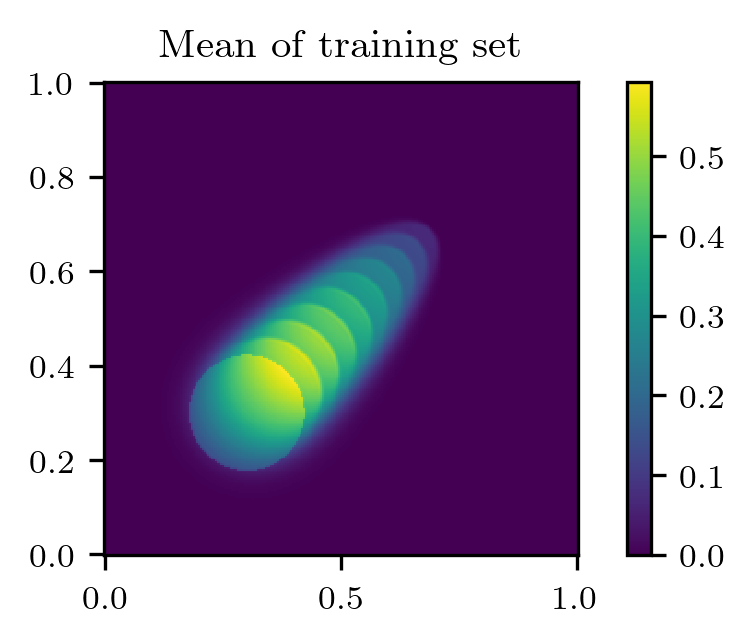

In [5]:
mean_train = np.mean(X_train, axis=0).reshape(shape)

fig, ax = plt.subplots()
cs = ax.pcolormesh(X_mesh, Y_mesh, mean_train)
plt.colorbar(cs, ax=ax)
ax.set_title("Mean of training set")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## Case dict and target function

Precomputed `X_train_n`, `X_test_n` (normalized); we smooth training data on GPU and use `get_predictions_gpu` (RL deconvolution uses `richardson_lucy2_gpu`).

In [6]:
n_test = X_test.shape[0]
case = {
    "sigma": 0.01628,
    "c": 0.5617,
    "num_iter": 20,
    "shape": shape,
    "x": x,
    "dx": dx,
    "mode": "reflect",
    "sigmaD": "calc_based_on_distance",
    "mu_train": mu_train,
    "mu_test": mu_test,
    "n_test": n_test,
    "rank": rank
}


def smoothen_GPU(X_train_gpu, shape, sgm, mode):
    #X_train_gpu = cp.asarray(X_train.reshape(-1, *shape).astype(np.float32))
    m0 = cp.sum(X_train_gpu, axis=(1, 2), keepdims=True)
    out = gaussian_filter_gpu(X_train_gpu, sigma=(0, sgm, sgm), truncate=8, mode=mode)
    m1 = cp.sum(out, axis=(1, 2), keepdims=True)
    out = out * cp.where(m1 > 0, m0 / m1, 1.0)
    X_train_s = cp.asnumpy(out).reshape(len(X_train_gpu), -1)
    return X_train_s


def target_function(case, X_train_gpu, mu_, u_max, X_e=None):
    sgm = case["sigma"] / case["dx"]
    mode = case["mode"]
    shape = case["shape"]
    mu_train = case["mu_train"]
    print(len(mu_train), len(mu_), case["sigma"], case["c"], case["sigmaD"][0], case["num_iter"], end=" ")
    X_train_s = smoothen_GPU(X_train_gpu, shape, sgm, mode)
    #print(mu_train.shape, X_train.shape, X_train.shape)
    my_ROM = train_ROM_rw(mu_train, X_train)
    my_sROM = train_ROM_rw(mu_train, X_train_s)
    X___ROM = my_ROM.predict(mu_).snapshots_matrix

    #u_max = np.interp(mu_, mu_train.ravel(), X_train.max(axis=1)).ravel()
    #u_max = np.ones_like(mu_).ravel()*np.max(X_train)
    t1 = datetime.now()
    X___sROM, X___sROMs = get_predictions_gpu(my_sROM, mu_, cmax=u_max, **case)
    t2 = datetime.now()

    mean_ROM, mean_sROM, mean_sROMs, improvement = get_improvement(
        X_e, X___ROM, X___sROM, X___sROMs, norm=L2_error_rw, scaler=False
    )
    print(mean_ROM, mean_sROM, mean_sROMs, (t2-t1).total_seconds(), improvement)
    return mean_ROM, mean_sROM, mean_sROMs, X___ROM, X___sROM, X___sROMs

In [7]:
u_max = np.interp(mu_test, mu_train.ravel(), X_train.max(axis=1)).ravel()
#u_max = np.ones_like(mu_train).ravel()*np.max(X_train)
X_train_gpu = cp.asarray(X_train.reshape(-1, *shape).astype(np.float32))
mean_ROM, mean_sROM, mean_sROMs, X_test_ROM, X_test_sROM, X_test_sROMs = target_function(case, X_train_gpu, mu_test, u_max, X_e=X_test)
e_ROM = L2_error_rw(X_test_ROM, X_test)
e_sROM = L2_error_rw(X_test_sROM, X_test)
e_sROMs = L2_error_rw(X_test_sROMs, X_test)

for i in range(len(e_ROM)):
    sgm_est = get_sigma(case["sigma"], mu_test[i][None, ...], mu_train, c=case["c"])
    print(i,mu_test[i], u_max[i], np.max(X_test[i]), np.max(X_test_sROMs[i]), sgm_est, e_ROM[i], e_sROM[i], e_sROMs[i], 100 * e_sROMs[i] / e_ROM[i] - 100)

10 20 0.01628 0.5617 c 20 0.024658813521332434 0.027742698028751518 0.01867170443745752 1.535466 -24.27979382988336
0 [0.682] 0.8253176550451713 0.818551834098659 0.79965764 0.01792600568 0.014657419773297785 0.02049301596771086 0.009139263320072963 -37.64752963736186
1 [0.642] 0.8570136220036287 0.8494035892741593 0.84383094 0.02012067992 0.024330654920913786 0.023975453285560566 0.01975070114510256 -18.823799814260056
2 [0.179] 1.1156509091055018 1.1162757203726565 1.0733333 0.01820033996 0.036944488261826364 0.036818705779324896 0.023845217189028798 -35.45663152772006
3 [0.87] 0.7123541534811583 0.7099293458838755 0.6914096 0.019023342800000002 0.013989152000697927 0.0175344587624044 0.008751964359729102 -37.43749185588618
4 [0.755] 0.7764175472709828 0.7742254569117398 0.77641755 0.020395014200000006 0.01991212625967841 0.0207731040515985 0.014454178684101865 -27.410169584092884
5 [0.68] 0.8269024533930942 0.8249951761370004 0.7879508 0.018108895200000003 0.015862716911013323 0.020

8 0.021220831972158048 0.024294480167646584 0.024294480167646584 -39.350598814340465


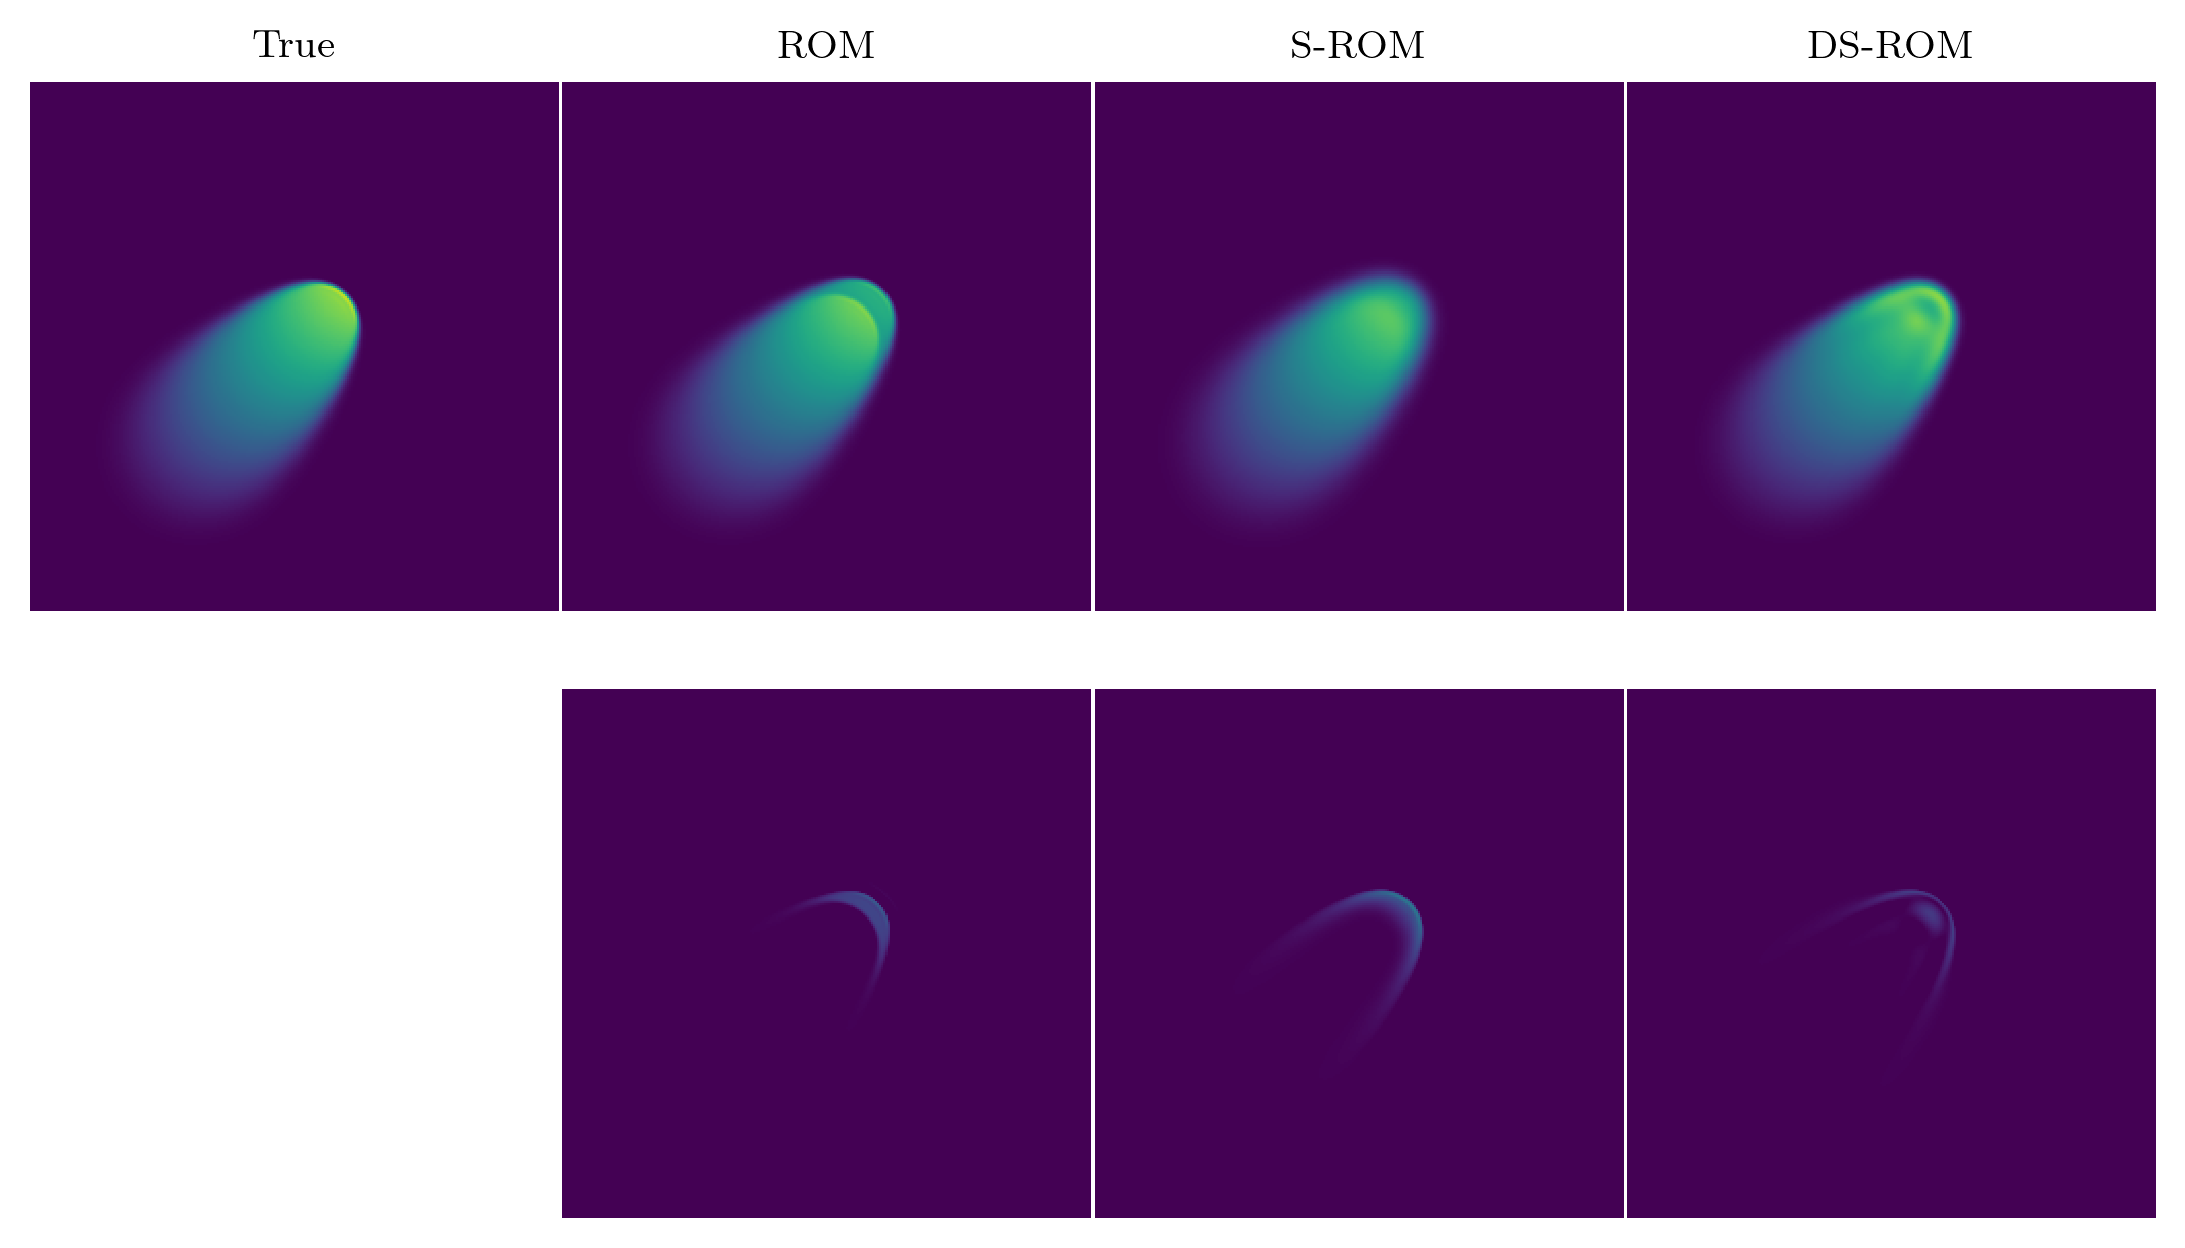

2 0.036944488261826364 0.036818705779324896 0.036818705779324896 -35.45663152772006


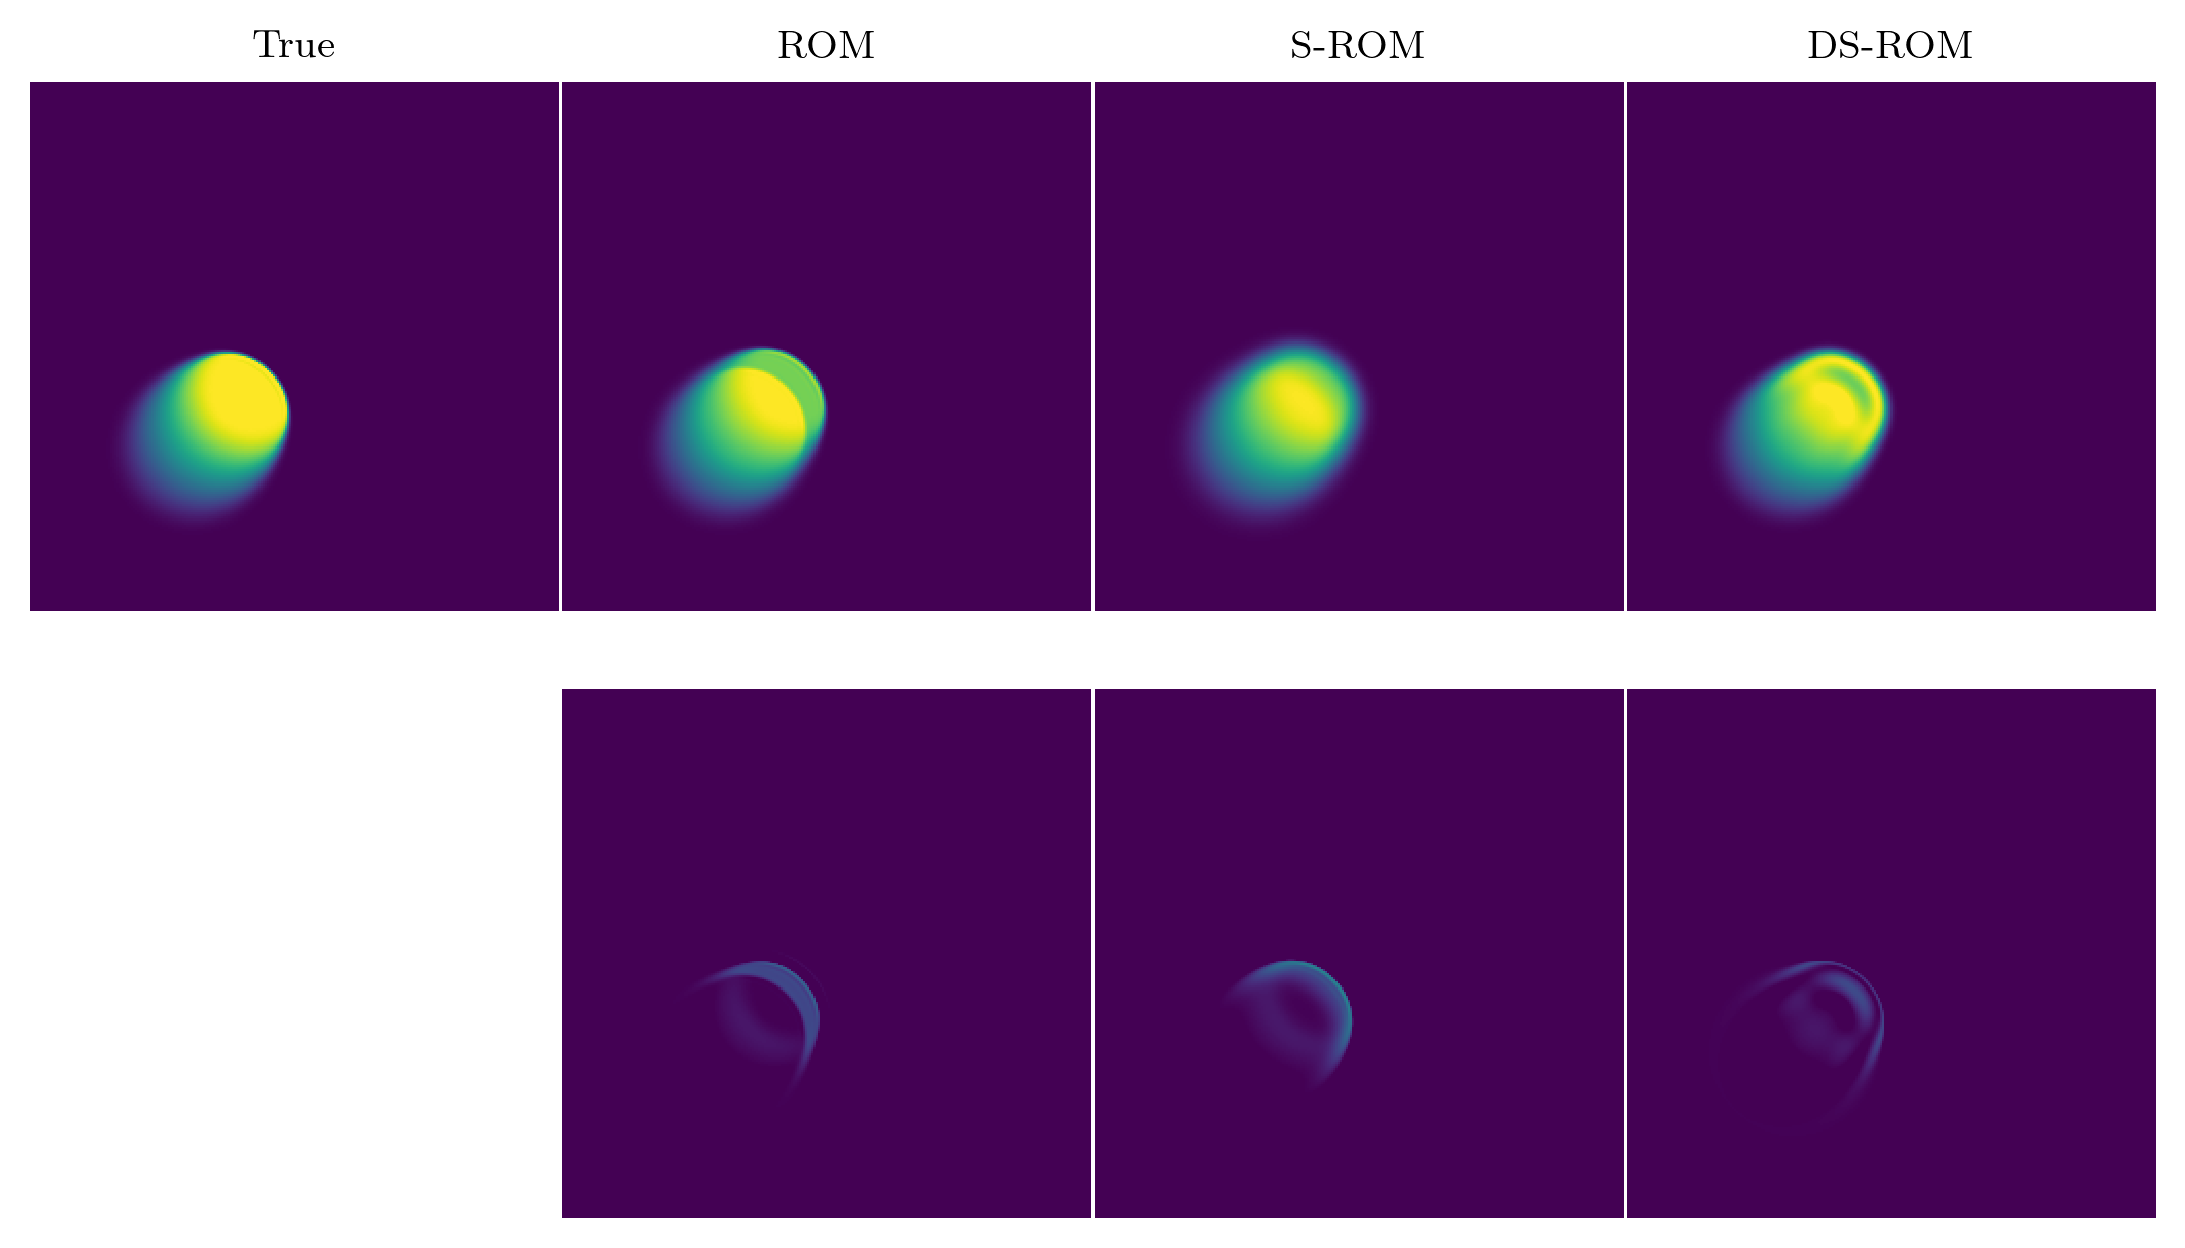

In [8]:
for i in [8, 2]:
    print(i, e_ROM[i], e_sROM[i], e_sROM[i], 100 * e_sROMs[i] / e_ROM[i] - 100)
    fig, axs = plt.subplots(2, 4,  figsize=(single_column_in*2, single_column_in*2/1.618))
    for col, (Z, title) in enumerate([
        (X_test[i], "True"),
        (X_test_ROM[i], "ROM"),
        (X_test_sROM[i], "S-ROM"),
        (X_test_sROMs[i], "DS-ROM"),
    ]):
        ax = axs[0, col]
        ax.pcolormesh(X_mesh, Y_mesh, Z.reshape(shape), vmin=0, vmax=1, shading="nearest", rasterized=True)
        ax.set_aspect("equal")
        ax.set_title(title)
        ax.set_axis_off()
        
        ax = axs[1, col]
        ax.set_aspect("equal")
        ax.set_axis_off()
        if col != 0:
            ax.pcolormesh(X_mesh, Y_mesh, (X_test[i]-Z).reshape(shape), vmin=0, vmax=1, shading="nearest", rasterized=True)
    plt.tight_layout(pad=0.0, w_pad=0.1, h_pad=0.1)
    pth = "../Plots/Burgers2D_ss"+str(i)
    plt.savefig(pth+"_results.pdf")
    plt.show()

## Optimization (sigma, sigmaD)

In [9]:
use_mu_adaptive_rule = True
num_iter = 20
ranks = [10, 20, 30, 50, 100]
params_opt = [[None] for i in range(len(ranks))]
for i, rank in enumerate(ranks):
    #for num_iter in [10, 20, 30, 50, 75, 100]:
        X_train, mu_train, X_val, mu_val, X_test, mu_test = split_train_test_val(X_val_all, mu_val_all, rank)

        X_train_gpu = cp.asarray(X_train.reshape(-1, *shape).astype(np.float32))
        u_max = np.interp(mu_test, mu_train.ravel(), X_train.max(axis=1)).ravel()

        #print(mu_test.shape, X_test.shape, mu_test[[0, -1], :].ravel())
        print(X_train.shape, X_test.shape, X_val.shape)
        print(mu_train.shape, mu_test.shape, mu_val.shape)
        
        #rank = len(mu_train)
       # print(rank, 2 * sigma_opt)
        case["sigmaD"] = np.ones_like(mu_test.ravel())
        def _target1(params):
            case["c"] = False
            case["mu_train"] = mu_train
            case["sigma"], case["sigmaD"][:] = params[0], params[1]
            return target_function(case, X_train_gpu, mu_test, u_max, X_e=X_test)[2]

        def _target2(params):
            case["sigmaD"] = "calc_based_on_distance"
            case["mu_train"] = mu_train
            case["sigma"], case["c"] = params[0], params[1]
            return target_function(case, X_train_gpu, mu_test, u_max, X_e=X_test)[2]
        
        def _target3(params):
            case["mu_train"] = mu_train
            case["sigma"], case["c"], case["num_iter"] = params[0], params[1], int(round(params[2]))
            return target_function(case, X_train_gpu, mu_test, u_max, X_e=X_test)[2]
        sigma_opt = 0.23/rank
        bounds1 = Bounds([0.001, 0.001], [2 * sigma_opt, 3 * sigma_opt])
        bounds2 = Bounds([0.001, 0], [2 * sigma_opt, 3])

        case["num_iter"] = num_iter

        if use_mu_adaptive_rule:
            _target=_target2
            bounds = bounds2
            case["c"] = 1.0
            case["sigmaD"] = "calc_based_on_distance"
        else:
            _target=_target1
            bounds = bounds1
            case["c"] = False
            case["sigmaD"] = np.ones_like(mu_test.ravel())
        t1 = datetime.now()
        res = direct(_target, bounds, eps=1e-2, len_tol=0.01)
        t2 = datetime.now()
        _target(res["x"])
        params_opt[i] = res["x"]
        print("DIRECT result:", res["x"], "mean_sROMs (min) =", res["fun"], (t2-t1).total_seconds(), "sec")
    
        #bounds3 = ([0.001, 0, 1], [5 * sigma_opt, 5, 200])
        #res = direct(_target2, bounds2, eps=1e-2, len_tol=0.01)

print(params_opt)

(10, 66049) (20, 66049) (871, 66049)
(10, 1) (20, 1) (871, 1)
10 20 0.0235 1.5 c 20 0.024658813521332434 0.033576290790645544 0.03451795401721302 2.401506 39.98221766570967
10 20 0.0385 1.5 c 20 0.024658813521332434 0.04613894210299689 0.048933642200298624 2.549681 98.44280892901008
10 20 0.0085 1.5 c 20 0.024658813521332434 0.023246523586405016 0.0227348002706589 1.411631 -7.802537818817044
10 20 0.0235 2.5 c 20 0.024658813521332434 0.033576290790645544 0.046376594878485354 1.964704 88.07309945535206
10 20 0.0235 0.5 c 20 0.024658813521332434 0.033576290790645544 0.021796825518720427 1.130758 -11.606349186817482
10 20 0.0385 0.5 c 20 0.024658813521332434 0.04613894210299689 0.03215125065567345 1.210957 30.38441864958054
10 20 0.0085 0.5 c 20 0.024658813521332434 0.023246523586405016 0.023869627077291664 0.838007 -3.2004234240955753
10 20 0.0385 2.5 c 20 0.024658813521332434 0.04613894210299689 0.0648357401078418 2.691033 162.93130467024355
10 20 0.0085 2.5 c 20 0.024658813521332434 0.

In [10]:
#params_opt = [[0.02016667, 0.35185185], [0.01145679, 0.5       ], [0.00846159, 0.53703704], [0.00628107, 0.35185185],  [0.00459259, 0.14197531] ]  # n_iter = 50?

# testing

(10, 66049) (20, 66049) (871, 66049)
(10, 1) (20, 1) (871, 1)
10 871 0.016277777777777776 0.5493827160493828 c 20 0.02626438532309778 0.029634485716506745 0.023092112724512 68.804047 -12.078228976468651
75.495329


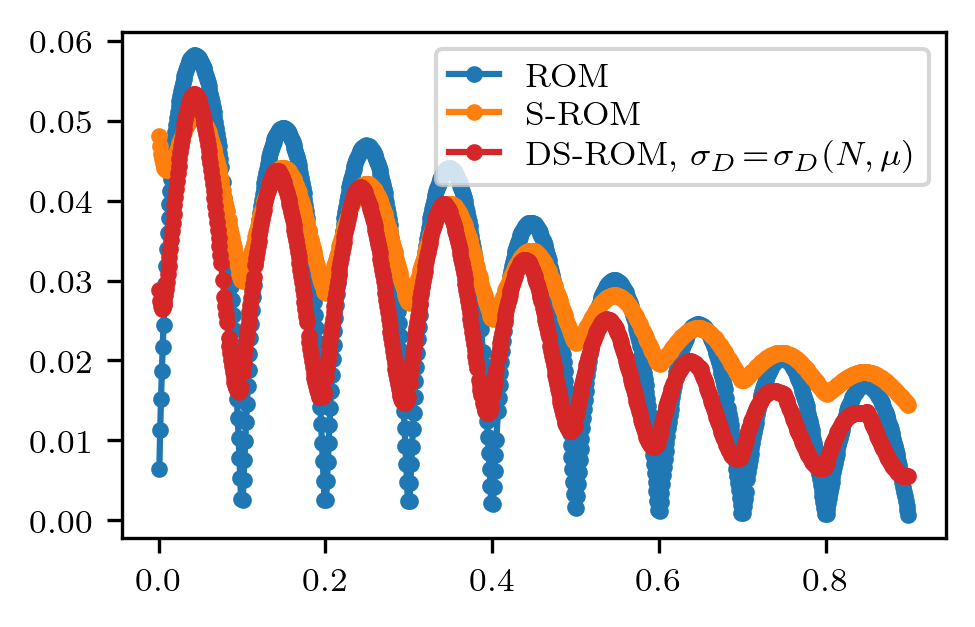

(20, 66049) (20, 66049) (911, 66049)
(20, 1) (20, 1) (911, 1)
20 911 0.009012345679012344 0.8209876543209877 c 20 0.014532860879035913 0.01743916113087596 0.01161483119849644 73.104942 -20.07883860464679
79.753689


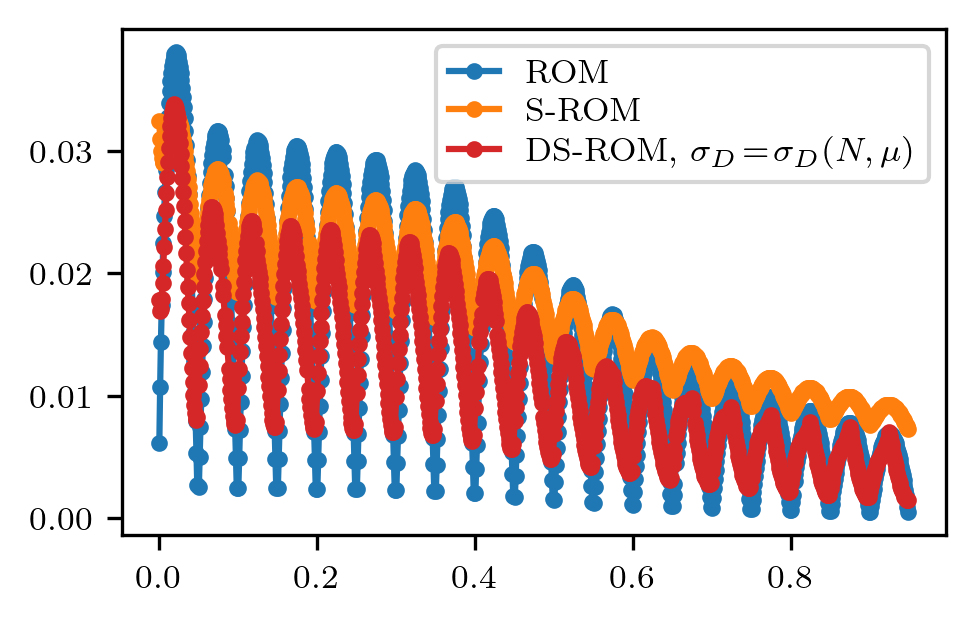

(30, 66049) (20, 66049) (937, 66049)
(30, 1) (20, 1) (937, 1)
30 937 0.006633058984910837 0.8580246913580247 c 20 0.009798074141690158 0.012653754246710305 0.007218110644817654 74.42123 -26.33133266357855
81.149848


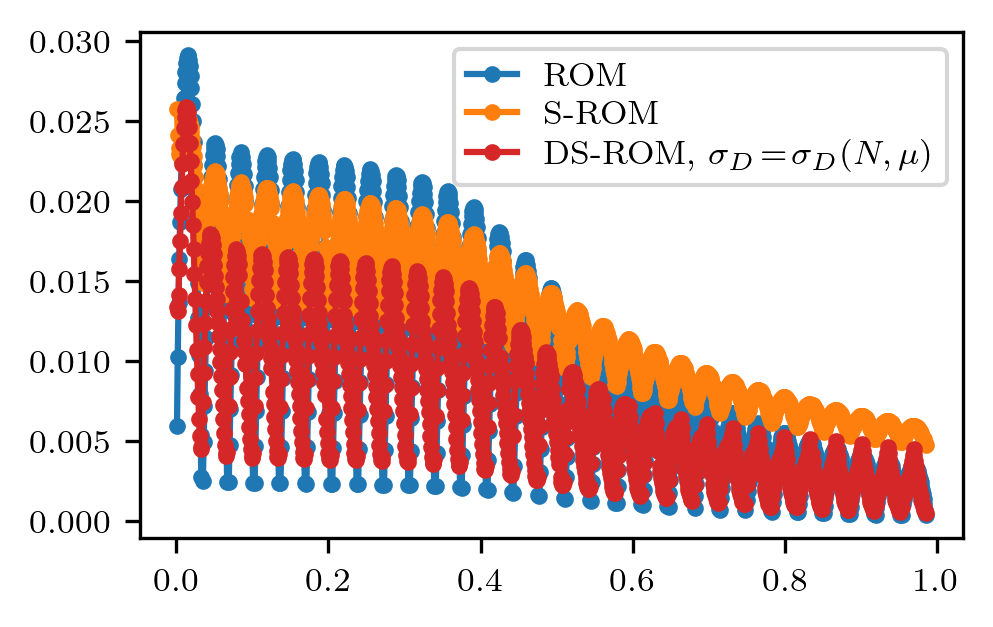

(50, 66049) (20, 66049) (911, 66049)
(50, 1) (20, 1) (911, 1)
50 911 0.00489753086419753 0.5987654320987654 c 20 0.005146324034451531 0.008583934280111944 0.0033991644357348454 71.627607 -33.94966168124097
79.249248


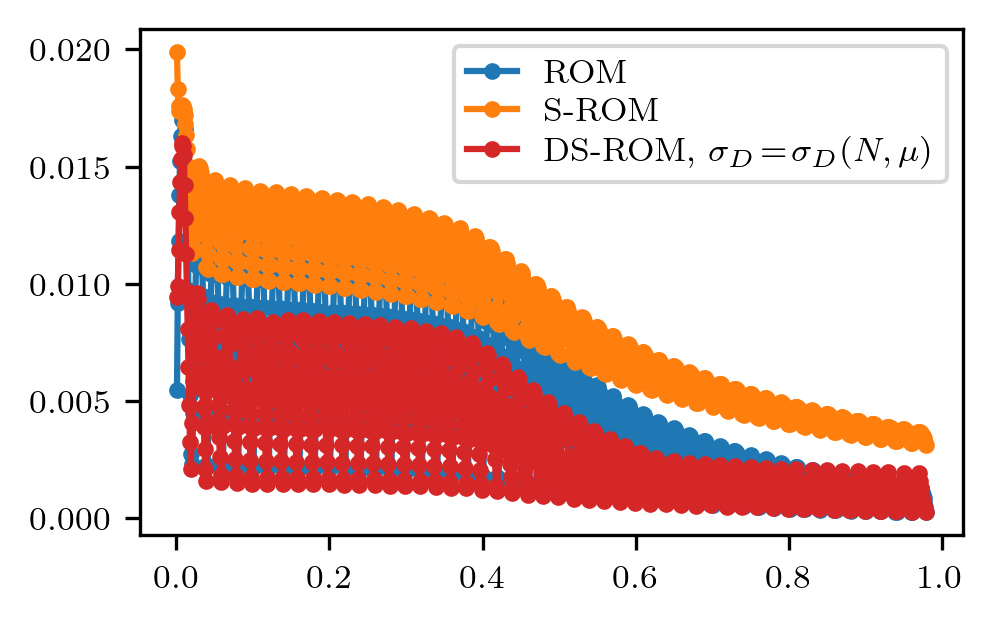

(100, 66049) (20, 66049) (871, 66049)
(100, 1) (20, 1) (871, 1)
100 871 0.004192592592592592 0.22839506172839513 c 20 0.0016543534161254539 0.006117499562580726 0.0010647638485066337 67.369419 -35.63867078653949
76.137129


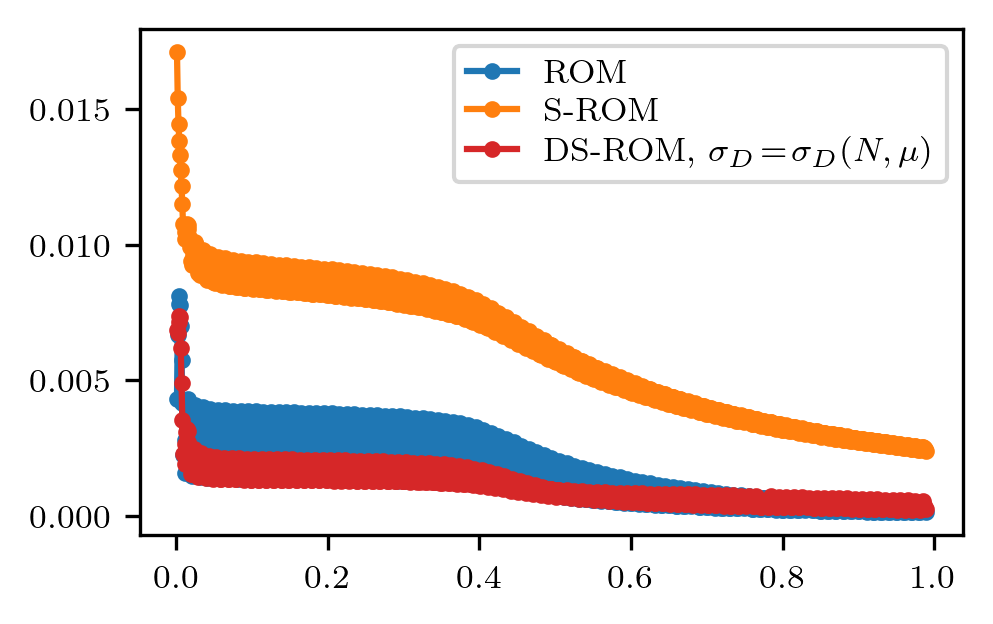

In [11]:
for i, rank in enumerate(ranks):
    X_train, mu_train, X_val, mu_val, X_test, mu_test = split_train_test_val(X_val_all, mu_val_all, rank)
    case["num_iter"] = 20
    if use_mu_adaptive_rule:
        case["sigma"], case["c"], case["sigmaD"] = params_opt[i][0], params_opt[i][1], "calc_based_on_distance"
    else:
        case["sigma"], case["c"], case["sigmaD"] = params_opt[i][0], False, np.ones_like(mu_val.ravel())*params_opt[i][1]
    
    X_train_gpu = cp.asarray(X_train.reshape(-1, *shape).astype(np.float32))
    u_max = np.interp(mu_val, mu_train.ravel(), X_train.max(axis=1)).ravel()
    #print(mu_test.shape, X_test.shape, mu_test[[0, -1], :].ravel())
    print(X_train.shape, X_test.shape, X_val.shape)
    print(mu_train.shape, mu_test.shape, mu_val.shape)

    case["mu_train"] = mu_train
    t1 = datetime.now()
    mean_ROM, mean_sROM, mean_sROMs, X_val_ROM, X_val_sROM, X_val_sROMs = target_function(case, X_train_gpu, mu_val, u_max, X_e=X_val)
    t2 = datetime.now()
    print((t2-t1).total_seconds())
    e_ROM = L2_error_rw(X_val_ROM, X_val)
    e_sROM = L2_error_rw(X_val_sROM, X_val)
    e_sROMs = L2_error_rw(X_val_sROMs, X_val)
    fig, ax = plt.subplots()
    ax.plot(mu_val.ravel(), e_ROM.ravel(), "C0o-", ms=3, label=r"ROM")
    ax.plot(mu_val.ravel(), e_sROM.ravel(), "C1o-", ms=3, label=r"S-ROM")
    ax.plot(mu_val.ravel(), e_sROMs.ravel(), "C3o-", ms=3, label=r"DS-ROM, $\sigma_D\!=\!\sigma_D(N, \mu)$")  #  (\sigma_S, c)
    plt.legend()
    plt.show()

# DS-ROM + projection: best coefficients are assumed to be known

In [11]:
def target_function_best_coeff(case, X_train_gpu, mu_, u_max, X_e=None, X_eGPU=None):
    sgm = case["sigma"] / case["dx"]
    mode = case["mode"]
    shape = case["shape"]
    mu_train = case["mu_train"]
    sigma = case["sigma"]
    c = case["c"]
    x = case["x"]
    num_iter = case["num_iter"]
    
    print(len(mu_train), len(mu_), case["sigma"], case["c"], case["sigmaD"][0], case["num_iter"], end=" ")
    X_train_s = smoothen_GPU(X_train_gpu, shape, sgm, mode)
    #print(mu_train.shape, X_train.shape, X_train.shape)
    #U1, S, VT = np.linalg.svd(X_train.T, full_matrices=False)
    #U2, S, VT = np.linalg.svd(X_train_s.T, full_matrices=False)
    Q1, R1 = np.linalg.qr(X_train.T, mode="reduced")
    Q2, R2 = np.linalg.qr(X_train_s.T, mode="reduced")
    #G = X_train @ X_train.T                      # (n_snap, n_snap)
    #Ginv = np.linalg.pinv(G, rcond=rcond)
    #Gs = X_train_s @ X_train_s.T                      # (n_snap, n_snap)
    #Gsinv = np.linalg.pinv(Gs, rcond=rcond)

    # we assume we know the exact coefficients. here we compute them using the exact solution (U2.T @X_test_s.T)
    X_e_s = smoothen_GPU(X_eGPU, shape, sgm, mode)
    #X___ROM = (U1 @ (U1.T @X_e.T)).T
    #X___sROM = (U2 @ (U2.T @X_e_s.T)).T
    X___ROM = (Q1 @ (Q1.T @X_e.T)).T
    X___sROM = (Q2 @ (Q2.T @X_e_s.T)).T
    # X___ROM = (X_e @ X_train.T) @ Ginv @ X_train
    # X___sROM = (X_e_s @ X_train_s.T) @ Gsinv @ X_train_s
    
    #my_ROM = train_ROM_rw(mu_train, X_train)
    #my_sROM = train_ROM_rw(mu_train, X_train_s)
    #X___ROM = my_ROM.predict(mu_).snapshots_matrix
    #print(mu_.shape, mu_train.shape, X_train.shape)
    #u_max = np.ones_like(mu_).ravel()*np.max(X_train)

    cmax = u_max
    sigmaD = case["sigmaD"]
    #deconvolved = np.empty_like(X___sROM)
    deconvolved_gpu = cp.empty(X___sROM.shape)
    # Transfer all data to GPU once
    data_gpu = cp.asarray(X___sROM.astype(np.float32))
    t1 = datetime.now()

    if isinstance(sigmaD, np.ndarray):
        sgm_est = sigmaD
    elif sigmaD == "calc_based_on_distance":
        sgm_est = get_sigma_batch(sigma, mu_, mu_train, c=c)
    else:
        raise ValueError("unknown method for sigmaD.")
    for j in range(len(mu_)):
        # if isinstance(sigmaD, np.ndarray):
        #     sgm_est = sigmaD[j]
        # elif sigmaD == "calc_based_on_distance":
        #     sgm_est = get_sigma(sigma, mu_[j][None, ...], mu_train, c=c)
        # else:
        #     raise ValueError("unknown method for sigmaD.")
        res = richardson_lucy2_gpu(x, data_gpu[j].reshape(shape), sgm_est[j], num_iter, mode=mode, clip_max=cmax[j])[0].reshape(deconvolved_gpu[j].shape)
        deconvolved_gpu[j] = res
    t2 = datetime.now()
    X___sROMs = cp.asnumpy(deconvolved_gpu)
    mean_ROM, mean_sROM, mean_sROMs, improvement = get_improvement(
        X_e, X___ROM, X___sROM, X___sROMs, norm=L2_error_rw, scaler=False
    )
    print(mean_ROM, mean_sROM, mean_sROMs, (t2-t1).total_seconds(), improvement)
    return mean_ROM, mean_sROM, mean_sROMs, X___ROM, X___sROM, X___sROMs

In [12]:
use_mu_adaptive_rule = True
ranks = [10, 20, 30, 50, 100]
case["num_iter"] = num_iter
params_opt_best_coeff = [[None] for i in range(len(ranks))]
for i, rank in enumerate(ranks):
    X_train, mu_train, X_val, mu_val, X_test, mu_test = split_train_test_val(X_val_all, mu_val_all, rank)

    X_train_gpu = cp.asarray(X_train.reshape(-1, *shape).astype(np.float32))
    X_test_gpu = cp.asarray(X_test.reshape(-1, *shape).astype(np.float32))
    
    u_max = np.interp(mu_test, mu_train.ravel(), X_train.max(axis=1)).ravel()


    case["sigmaD"] = np.ones_like(mu_test.ravel())
    def _target1(params):
        case["c"] = False
        case["mu_train"] = mu_train
        case["sigma"], case["sigmaD"][:] = params[0], params[1]
        return target_function_best_coeff(case, X_train_gpu, mu_test, u_max, X_e=X_test, X_eGPU=X_test_gpu)[2]

    def _target2(params):
        case["mu_train"] = mu_train
        case["sigma"], case["c"] = params[0], params[1]
        return target_function_best_coeff(case, X_train_gpu, mu_test, u_max, X_e=X_test, X_eGPU=X_test_gpu)[2]

    sigma_opt = 0.23/rank
    bounds1 = Bounds([0.001, 0.001], [2 * sigma_opt, 3 * sigma_opt])
    bounds2 = Bounds([0.001, 0], [2 * sigma_opt, 3])

    if use_mu_adaptive_rule:
        _target=_target2
        bounds = bounds2
        case["c"] = 1.0
        case["sigmaD"] = "calc_based_on_distance"
    else:
        _target=_target1
        bounds = bounds1
        case["c"] = False
        case["sigmaD"] = np.ones_like(mu_test.ravel())
    
    #bounds = Bounds([0.001, 0, 1], [5 * sigma_opt, 5, 200])
    case["num_iter"] = num_iter
    t1 = datetime.now()
    res = direct(_target, bounds, eps=1e-2, len_tol=0.01)
    t2 = datetime.now()
    params_opt_best_coeff[i] = res["x"]
    _target(res["x"])
    print("DIRECT result:", res["x"], "mean_sROMs (min) =", res["fun"], (t2-t1).total_seconds())
print(params_opt_best_coeff)

10 20 0.0235 1.5 c 20 0.02420071374634794 0.031016208393136215 0.03655006275661893 2.093259 51.02886278358045
10 20 0.0385 1.5 c 20 0.02420071374634794 0.04448694433464295 0.049849061012270435 1.396425 105.9817802679188
10 20 0.0085 1.5 c 20 0.02420071374634794 0.021274146115832636 0.018604231898980857 1.137331 -23.125275998157832
10 20 0.0235 2.5 c 20 0.02420071374634794 0.031016208393136215 0.048093436283142596 1.155938 98.72734658662799
10 20 0.0235 0.5 c 20 0.02420071374634794 0.031016208393136215 0.022560064244388972 1.210756 -6.779343448936729
10 20 0.0085 2.5 c 20 0.02420071374634794 0.021274146115832636 0.023239409569246507 1.169268 -3.9722141552395414
10 20 0.0085 0.5 c 20 0.02420071374634794 0.021274146115832636 0.017699986217765577 1.252803 -26.861718198552595
10 20 0.0385 2.5 c 20 0.02420071374634794 0.04448694433464295 0.06540419470898703 1.495917 170.2572965181946
10 20 0.0385 0.5 c 20 0.02420071374634794 0.04448694433464295 0.032499853437739167 1.439034 34.29295424249056

## testing



In [14]:
#params_opt_best_coeff = [np.array([0.01664815, 0.00617284]), np.array([0.0101893 , 0.00617284]), np.array([0.00781276, 0.0308642 ]), np.array([0.00520123, 0.00617284]), np.array([0.00106667, 0.08024691])]

10 871 0.017203703703703704 0.006172839506172921 c 20 0.025889599637988477 0.027822693640836945 0.016068568402223697 66.998705 -37.934272345232124
75.320368


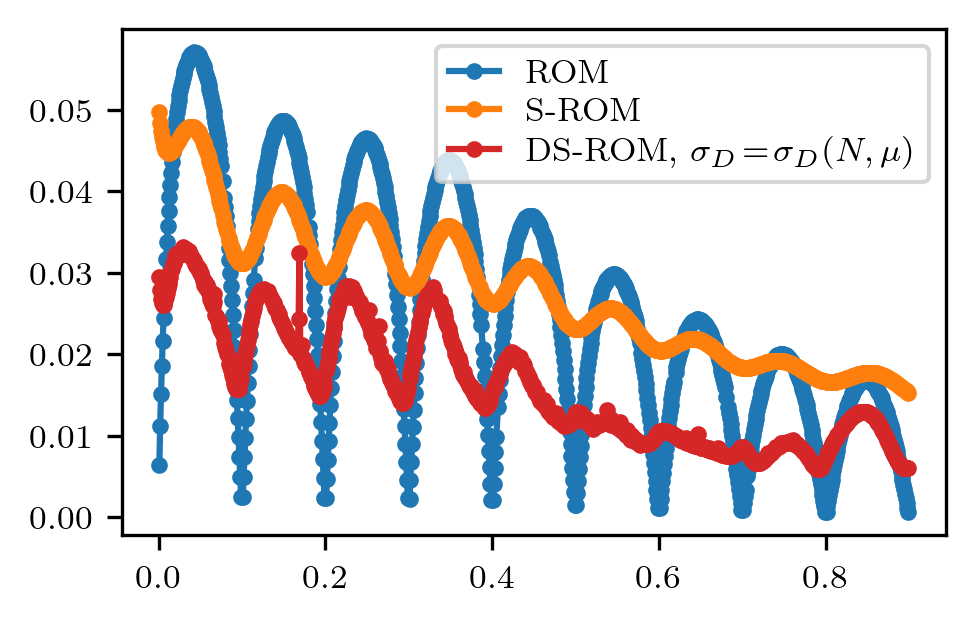

20 911 0.010098765432098766 0.0185185185185186 c 20 0.014134916916752947 0.016561495284276542 0.006909649381526188 69.850595 -51.116448563367555
79.004798


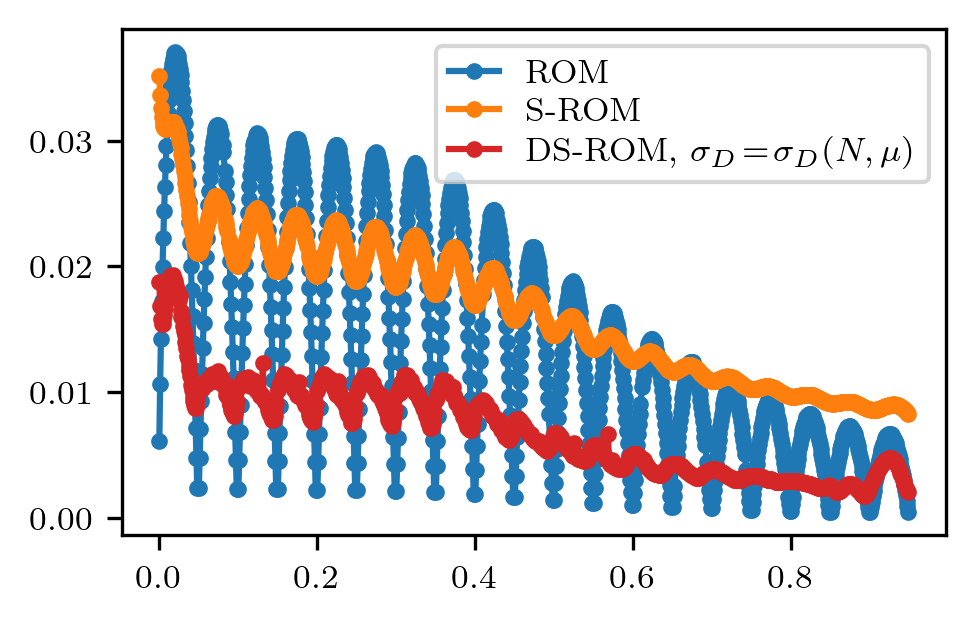

30 937 0.007871742112482854 0.006172839506172921 c 20 0.009285104710877568 0.012369986206475244 0.004122737865347059 71.238387 -55.598369714482146
81.187099


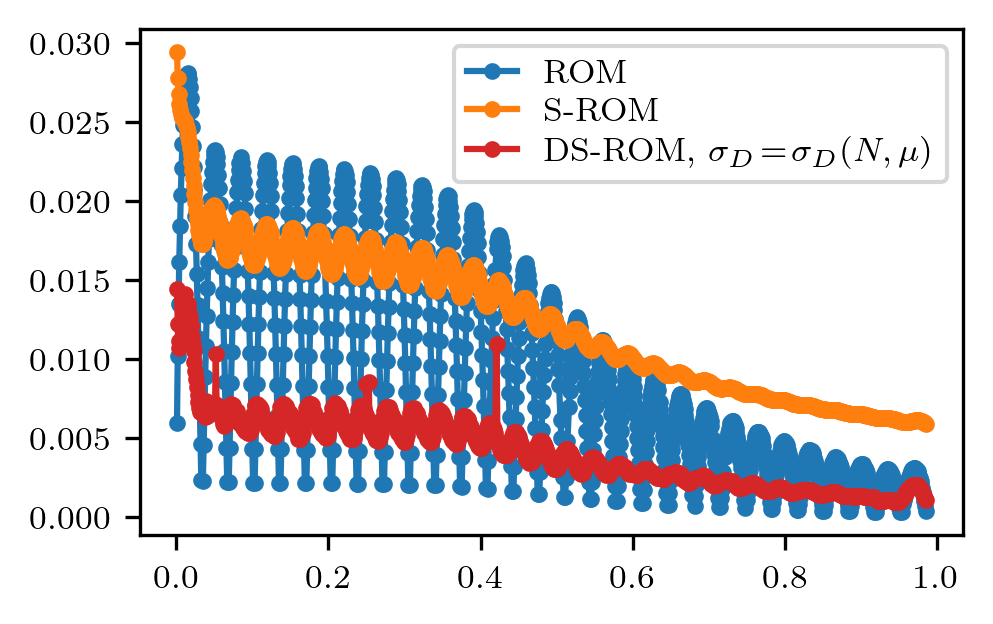

50 911 0.005234979423868313 0.006172839506172921 c 20 0.004330963680717206 0.0077028838632101325 0.001977798175662419 68.739174 -54.33353125383641
79.260356


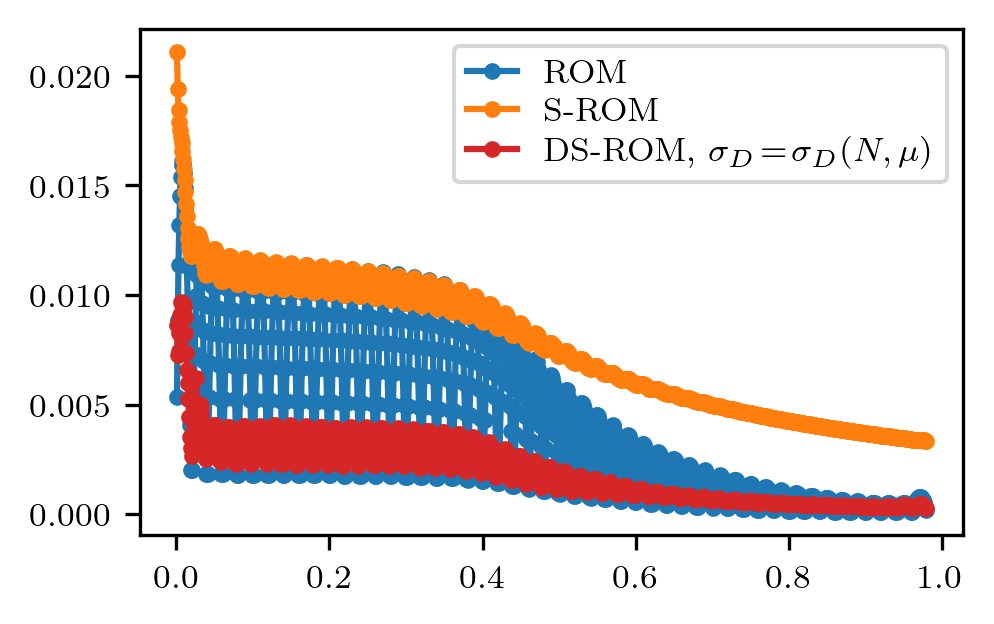

100 871 0.0010666666666666667 0.09259259259259267 c 20 0.000312984831553839 0.00031533882662326004 0.0005656972541769229 68.322571 80.74270608210378
82.868083


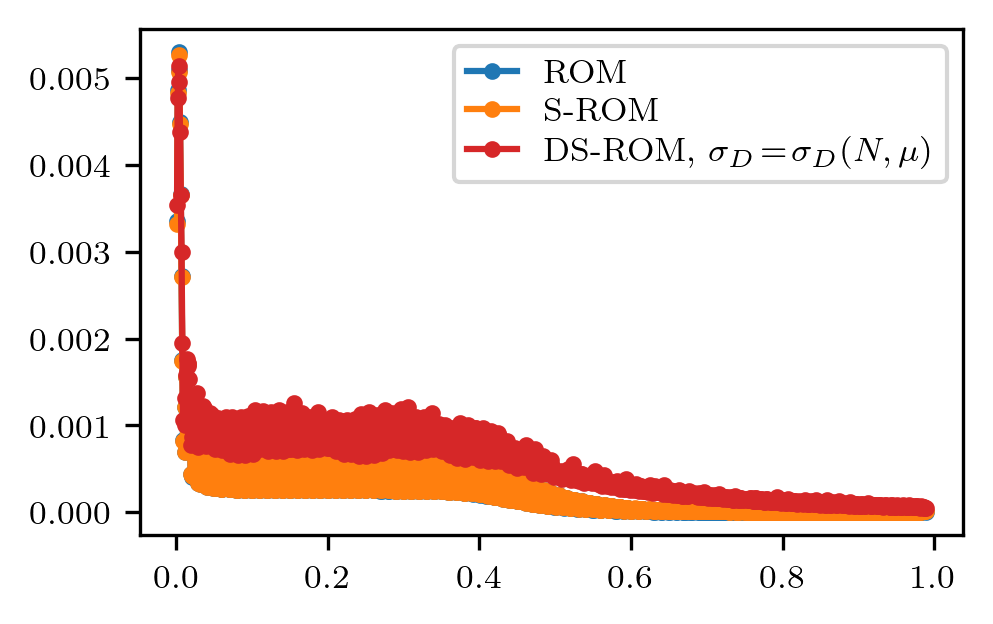

In [15]:
for i, rank in enumerate(ranks):
    X_train, mu_train, X_val, mu_val, X_test, mu_test = split_train_test_val(X_val_all, mu_val_all, rank)
    if use_mu_adaptive_rule:
        case["sigma"], case["c"], case["sigmaD"] = params_opt_best_coeff[i][0], params_opt_best_coeff[i][1], "calc_based_on_distance"
    else:
        case["sigma"], case["c"], case["sigmaD"] = params_opt_best_coeff[i][0], False, np.ones_like(mu_val.ravel())*params_opt_best_coeff[i][1]
    case["mu_train"] = mu_train
    u_max = np.interp(mu_val, mu_train.ravel(), X_train.max(axis=1)).ravel()
    X_train_gpu = cp.asarray(X_train.reshape(-1, *shape).astype(np.float32))
    X_test_gpu = cp.asarray(X_test.reshape(-1, *shape).astype(np.float32))
    X_val_gpu = cp.asarray(X_val.reshape(-1, *shape).astype(np.float32))

    t1 = datetime.now()
    mean_ROM, mean_sROM, mean_sROMs, X_val_ROM, X_val_sROM, X_val_sROMs = target_function_best_coeff(case, X_train_gpu, mu_val, u_max, X_e=X_val, X_eGPU=X_val_gpu)
    t2 = datetime.now()
    print((t2-t1).total_seconds())
    e_ROM = L2_error_rw(X_val_ROM, X_val)
    e_sROM = L2_error_rw(X_val_sROM, X_val)
    e_sROMs = L2_error_rw(X_val_sROMs, X_val)
    fig, ax = plt.subplots()
    ax.plot(mu_val.ravel(), e_ROM.ravel(), "C0o-", ms=3, label=r"ROM")
    ax.plot(mu_val.ravel(), e_sROM.ravel(), "C1o-", ms=3, label=r"S-ROM")
    ax.plot(mu_val.ravel(), e_sROMs.ravel(), "C3o-", ms=3, label=r"DS-ROM, $\sigma_D\!=\!\sigma_D(N, \mu)$")  #  (\sigma_S, c)
    plt.legend()
    plt.show()